# 02 — Exploratory analysis (delay-focused)

Reads `cleaned_flight_data.csv` from notebook **01**. Explores scale of delays, timing patterns, and airline/airport concentration to support delay cause attribution and clustering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 40)

In [2]:
df = pd.read_csv("cleaned_flight_data.csv", low_memory=False)
df["FlightDate"] = pd.to_datetime(df["FlightDate"])

if "IsArrivalDelayed" not in df.columns:
    df["IsArrivalDelayed"] = df["ArrDelay"] > 0

oper = df[df["Cancelled"] == 0].copy()
oper["ArrDelay"] = pd.to_numeric(oper["ArrDelay"], errors="coerce")
oper["DepDelay"] = pd.to_numeric(oper["DepDelay"], errors="coerce")

## 1. How big is the dataset?

Row count, date span, and completed (non-cancelled) flights used for delay views.

In [3]:
n = len(df)
n_op = len(oper)
d0, d1 = df["FlightDate"].min(), df["FlightDate"].max()
print(f"Rows: {n:,}")
print(f"Non-cancelled rows: {n_op:,} ({100 * n_op / n:.1f}%)")
print(f"FlightDate range: {d0.date()} — {d1.date()}")

Rows: 2,000,000
Non-cancelled rows: 1,963,538 (98.2%)
FlightDate range: 1987-10-01 — 2020-03-31


**Insight:** The analysis subset keeps only completed flights so arrival and departure delay minutes are defined; cancelled rows are retained in the file for completeness but excluded from delay-only charts.

## 2. How common are delays?

Share of flights with positive arrival delay among completed flights.

Share of flights with ArrDelay > 0: 43.8%


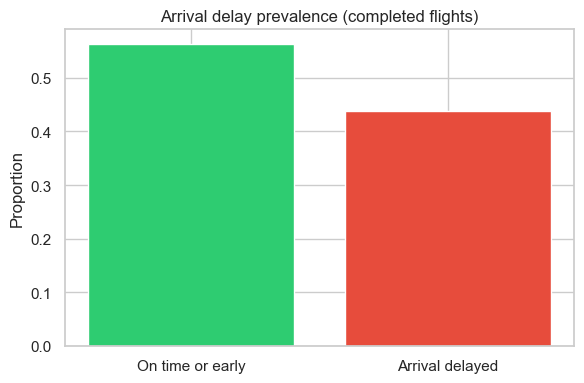

In [4]:
rate = oper["IsArrivalDelayed"].mean()
print(f"Share of flights with ArrDelay > 0: {100 * rate:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["On time or early", "Arrival delayed"], [1 - rate, rate], color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Proportion")
ax.set_title("Arrival delay prevalence (completed flights)")
plt.tight_layout()
plt.show()

**Insight:** The bar shows the baseline frequency of arrival delays; attribution work compares cause columns within this delayed subset and across carriers and airports.

## 3. When do delays occur?

Monthly averages and counts, then day-of-week and scheduled departure hour.

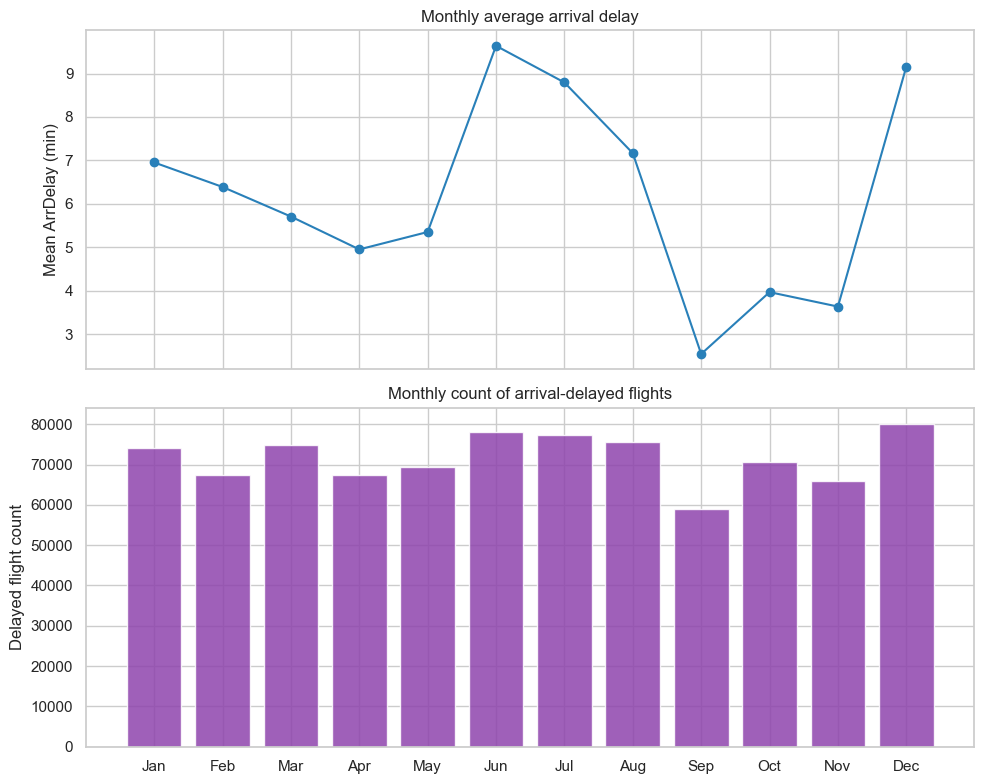

In [5]:
monthly_avg = oper.groupby("Month")["ArrDelay"].mean()
monthly_delayed = oper.groupby("Month")["IsArrivalDelayed"].sum()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[0].plot(monthly_avg.index, monthly_avg.values, marker="o", color="#2980b9")
axes[0].set_ylabel("Mean ArrDelay (min)")
axes[0].set_title("Monthly average arrival delay")
axes[1].bar(monthly_delayed.index, monthly_delayed.values, color="#8e44ad", alpha=0.85)
axes[1].set_ylabel("Delayed flight count")
axes[1].set_title("Monthly count of arrival-delayed flights")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(months)
plt.tight_layout()
plt.show()

**Insight:** Seasonal peaks in average delay and in raw delayed counts often diverge slightly because volume differs by month; both views matter for operational planning.

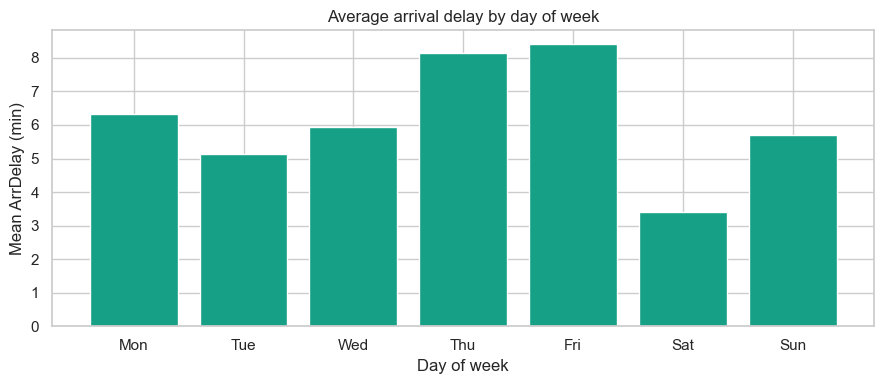

In [6]:
dow_map = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
by_dow = oper.groupby("DayOfWeek")["ArrDelay"].mean().reindex(range(1, 8))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 8), by_dow.values, color="#16a085")
ax.set_xticks(range(1, 8))
ax.set_xticklabels([dow_map[i] for i in range(1, 8)])
ax.set_xlabel("Day of week")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average arrival delay by day of week")
plt.tight_layout()
plt.show()

**Insight:** Mid-week versus weekend differences reflect both demand and operational slack; this motivates slicing attribution by `DayOfWeek` later.

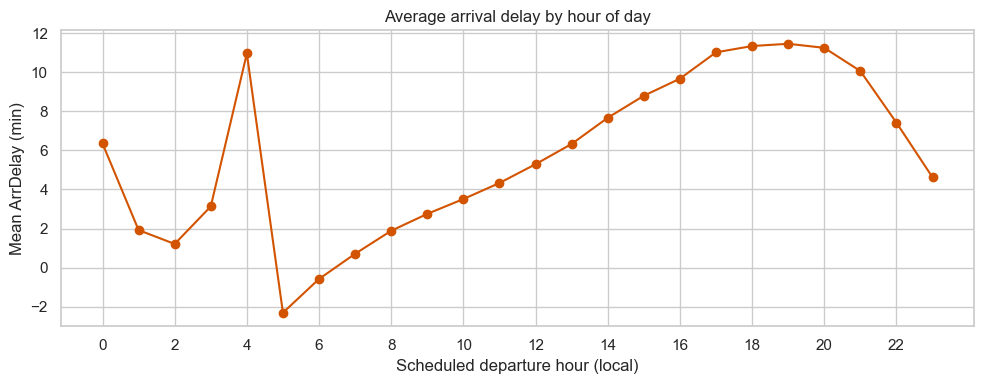

In [7]:
h = oper.dropna(subset=["DepHour"])
by_hour = h.groupby("DepHour")["ArrDelay"].mean().reindex(range(24))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(by_hour.index, by_hour.values, marker="o", color="#d35400")
ax.set_xlabel("Scheduled departure hour (local)")
ax.set_ylabel("Mean ArrDelay (min)")
ax.set_title("Average arrival delay by hour of day")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

**Insight:** Banked evening and late-day banks often show higher mean delays because disruptions propagate; cause attribution distinguishes NAS or late-aircraft effects from carrier-only effects.

## 4. Which airlines and airports are most affected?

Top 10 by mean arrival delay (minimum 500 flights per airline / origin to reduce noise).

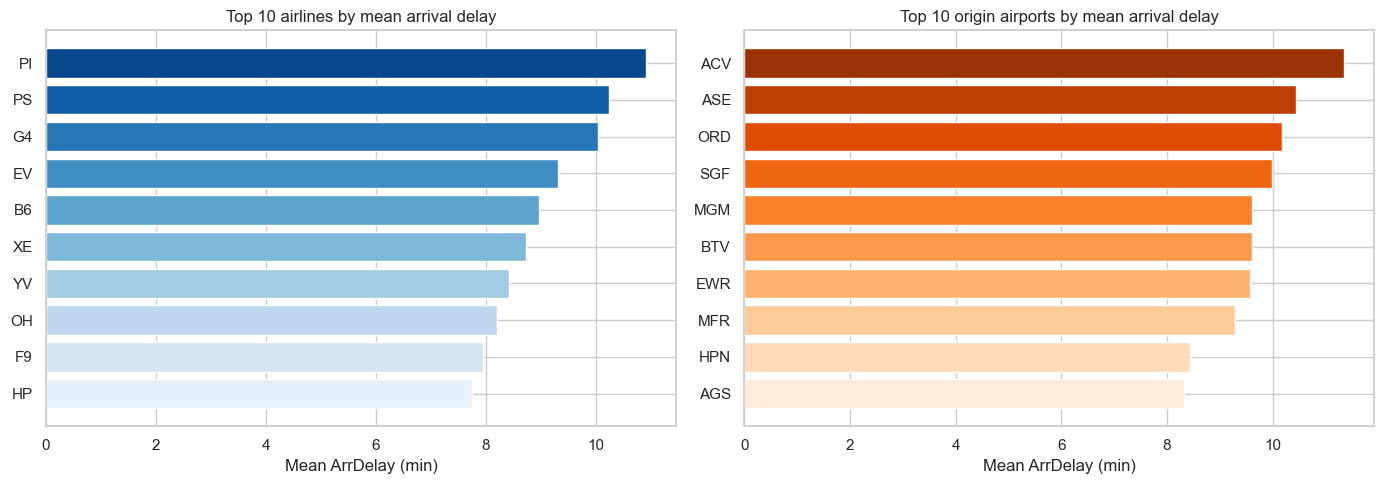

In [8]:
def top_by_mean_delay(gb_col, min_n=500, top_k=10):
    g = oper.groupby(gb_col).agg(n=("ArrDelay", "size"), mean_ad=("ArrDelay", "mean"))
    g = g[g["n"] >= min_n].sort_values("mean_ad", ascending=False).head(top_k)
    return g


top_airlines = top_by_mean_delay("Reporting_Airline")
top_airports = top_by_mean_delay("Origin")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(top_airlines.index.astype(str), top_airlines["mean_ad"], color=sns.color_palette("Blues_r", len(top_airlines)))
axes[0].invert_yaxis()
axes[0].set_xlabel("Mean ArrDelay (min)")
axes[0].set_title("Top 10 airlines by mean arrival delay")
axes[1].barh(top_airports.index.astype(str), top_airports["mean_ad"], color=sns.color_palette("Oranges_r", len(top_airports)))
axes[1].invert_yaxis()
axes[1].set_xlabel("Mean ArrDelay (min)")
axes[1].set_title("Top 10 origin airports by mean arrival delay")
plt.tight_layout()
plt.show()

**Insight:** Raw means emphasize chronic late performance or hard hubs; pairing this with cause-specific totals (in notebook 03) avoids blaming carriers for weather-heavy stations.

## 5. Arrival vs departure delay

Random sample for readability on large \(n\).

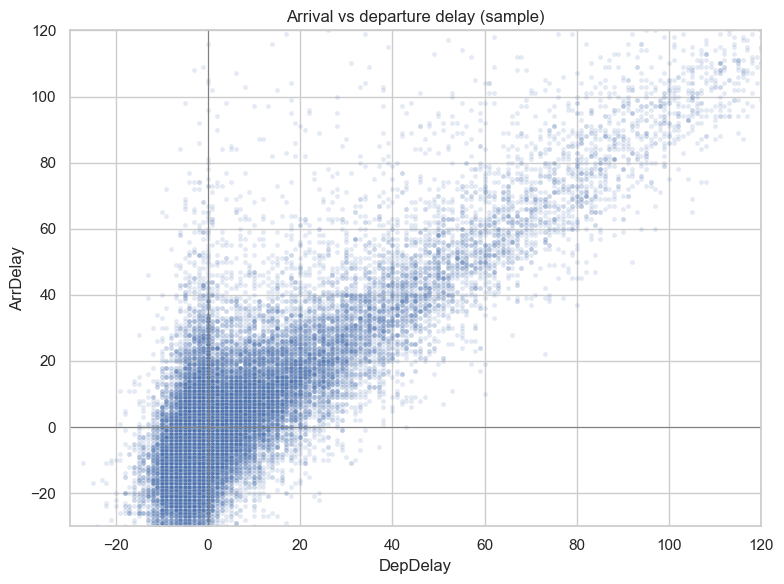

In [9]:
sample_n = min(50_000, len(oper))
sam = oper.sample(sample_n, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=sam, x="DepDelay", y="ArrDelay", alpha=0.15, s=12, ax=ax)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.set_xlim(-30, 120)
ax.set_ylim(-30, 120)
ax.set_title("Arrival vs departure delay (sample)")
plt.tight_layout()
plt.show()

**Insight:** Positive correlation shows propagated ground delays; points below the diagonal recover time in flight; extreme tails motivate cap or robust statistics in later notebooks.

## 6. Correlation heatmap (delay-related numerics)

Subset of columns most tied to delay minutes and causes.

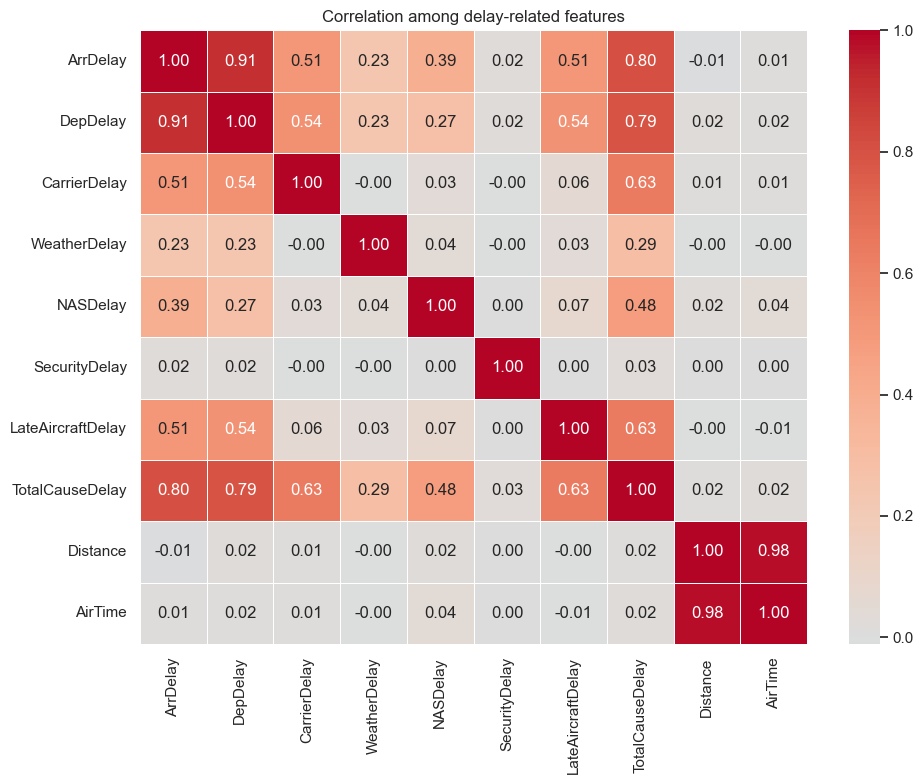

In [10]:
corr_cols = [
    c
    for c in [
        "ArrDelay",
        "DepDelay",
        "CarrierDelay",
        "WeatherDelay",
        "NASDelay",
        "SecurityDelay",
        "LateAircraftDelay",
        "TotalCauseDelay",
        "Distance",
        "AirTime",
    ]
    if c in oper.columns
]
cm = oper[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation among delay-related features")
plt.tight_layout()
plt.show()

**Insight:** Strong `DepDelay`–`ArrDelay` correlation is expected; among causes, late-aircraft and NAS often move together while weather is more orthogonal—useful for interpreting clusters built on cause profiles.